# Week 3 — Canonical PDEs: Heat Equation & Wave Equation
> **Goal:** Scale up from ODEs to PDEs. Use **DeepXDE** to solve the heat and wave equations, and study how collocation point count affects accuracy.

Install: `pip install deepxde`


In [4]:
import os
os.environ["DDE_BACKEND"] = "pytorch"
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "deepxde", "-q"])

import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm

dde.config.set_random_seed(42)
np.random.seed(42)
print(f"DeepXDE version: {dde.__version__}")

import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

DeepXDE version: 1.15.0
Using: cuda


---
## Part A — Heat Equation

**Problem:**
```
uₜ = 0.4 · u_xx,   x ∈ [0,1],  t ∈ [0,1]
u(0,t) = 0,   u(1,t) = 0          ← Dirichlet BCs
u(x,0) = sin(πx)                  ← Initial condition
```

**Analytical solution:** `u(x,t) = exp(−0.4π²t) · sin(πx)`


In [5]:
# ── Analytical solution ──────────────────────────────────────────────────────
def u_exact_heat(x):
    """x is an (N,2) array: x[:,0]=spatial, x[:,1]=temporal"""
    return np.exp(-0.4 * np.pi**2 * x[:, 1:2]) * np.sin(np.pi * x[:, 0:1])

alpha = 0.4   # diffusion coefficient

# ── PDE definition ────────────────────────────────────────────────────────────
def heat_pde(x, y):
    """PDE residual: u_t - alpha * u_xx = 0"""
    dy_t  = dde.grad.jacobian(y, x, i=0, j=1)     # ∂u/∂t
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)      # ∂²u/∂x²
    return dy_t - alpha * dy_xx

# ── Geometry & time domain ────────────────────────────────────────────────────
geom       = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime   = dde.geometry.GeometryXTime(geom, timedomain)

# ── Boundary & initial conditions ─────────────────────────────────────────────
bc = dde.icbc.DirichletBC(
    geomtime,
    lambda x: 0,                                   # u = 0 on boundary
    lambda _, on_boundary: on_boundary
)
ic = dde.icbc.IC(
    geomtime,
    lambda x: np.sin(np.pi * x[:, 0:1]),           # u(x,0) = sin(πx)
    lambda _, on_initial: on_initial
)

# ── Data, network, model ──────────────────────────────────────────────────────
data = dde.data.TimePDE(
    geomtime, heat_pde, [bc, ic],
    num_domain=2000, num_boundary=200, num_initial=200
)
net   = dde.nn.FNN([2] + [64]*4 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)

model.compile("adam", lr=1e-3)
losshistory, train_state = model.train(iterations=10000, display_every=2000)
print("Heat equation training complete ✓")

Compiling model...
'compile' took 1.298601 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [7.09e-03, 1.74e-01, 1.02e+00]    [7.09e-03, 1.74e-01, 1.02e+00]    []  


c:\Users\abhir\miniconda3\envs\soc26\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:370.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


2000      [1.58e-04, 1.14e-04, 1.34e-04]    [1.58e-04, 1.14e-04, 1.34e-04]    []  
4000      [2.85e-03, 1.78e-03, 1.45e-03]    [2.85e-03, 1.78e-03, 1.45e-03]    []  
6000      [2.37e-05, 2.80e-06, 2.85e-06]    [2.37e-05, 2.80e-06, 2.85e-06]    []  
8000      [1.62e-05, 2.00e-06, 2.02e-06]    [1.62e-05, 2.00e-06, 2.02e-06]    []  
10000     [1.21e-05, 1.77e-06, 1.57e-06]    [1.21e-05, 1.77e-06, 1.57e-06]    []  

Best model at step 10000:
  train loss: 1.54e-05
  test loss: 1.54e-05
  test metric: []

'train' took 61.689533 s

Heat equation training complete ✓


### Part A — Deliverable 1 & 2: Solution Surfaces (PINN vs Analytical)

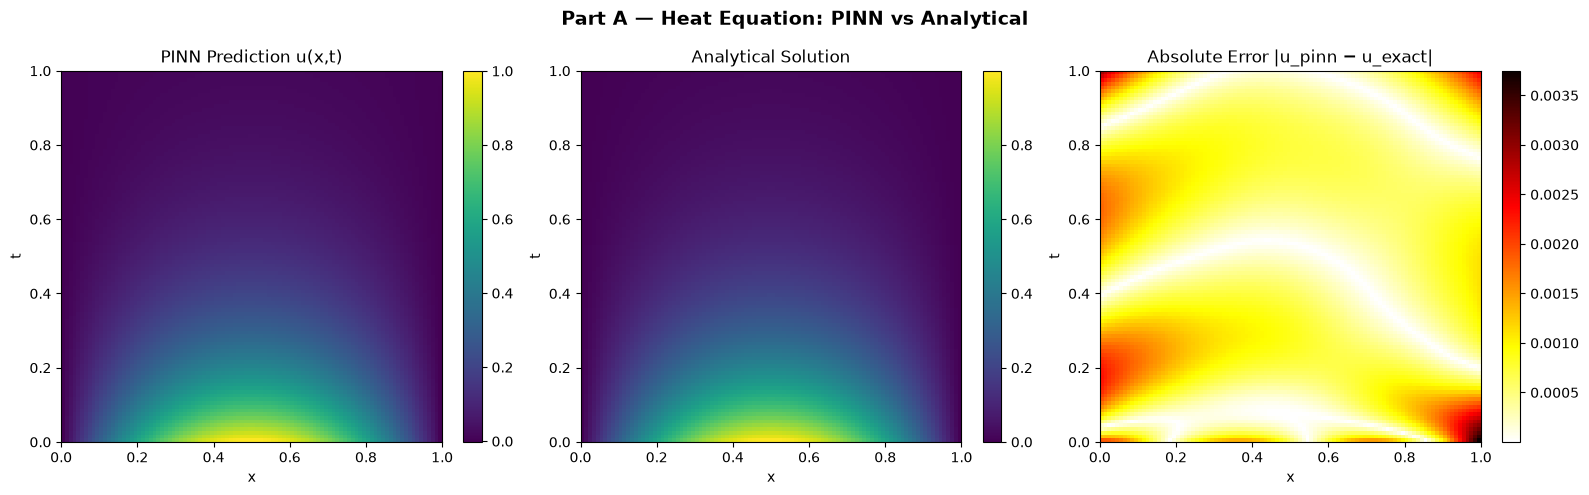

In [6]:
# Dense evaluation grid
x_plot = np.linspace(0, 1, 100)
t_plot = np.linspace(0, 1, 100)
X, T   = np.meshgrid(x_plot, t_plot)
XT     = np.column_stack([X.ravel(), T.ravel()])

u_pinn  = model.predict(XT).reshape(100, 100)
u_exact = u_exact_heat(XT).reshape(100, 100)
u_error = np.abs(u_pinn - u_exact)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Part A — Heat Equation: PINN vs Analytical", fontsize=14, fontweight="bold")

titles = ["PINN Prediction u(x,t)", "Analytical Solution", "Absolute Error |u_pinn − u_exact|"]
data_fields = [u_pinn, u_exact, u_error]
cmaps = ["viridis", "viridis", "hot_r"]

for ax, field, title, cmap in zip(axes, data_fields, titles, cmaps):
    im = ax.imshow(field, origin="lower", extent=[0, 1, 0, 1],
                   aspect="auto", cmap=cmap)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("x"); ax.set_ylabel("t")

plt.tight_layout()
plt.show()

### Part A — Deliverable 4: L² Relative Error

In [7]:
l2_heat = dde.metrics.l2_relative_error(u_exact.ravel(), u_pinn.ravel())
print(f"Final L² Relative Error (Heat Equation): {l2_heat:.4e}")

Final L² Relative Error (Heat Equation): 3.1435e-03


---
## Part B — Collocation Sampling Experiment

Repeat Part A with collocation counts `[500, 1000, 2500, 5000, 10000]`.
Plot L² relative error vs number of collocation points.


In [8]:
colloc_counts = [500, 1000, 2500, 5000, 10000]
l2_vs_colloc  = []

print("Running collocation experiment...")
for n_col in colloc_counts:
    # Rebuild data with this collocation count
    data_c = dde.data.TimePDE(
        geomtime, heat_pde, [bc, ic],
        num_domain=n_col, num_boundary=200, num_initial=200
    )
    net_c   = dde.nn.FNN([2] + [64]*4 + [1], "tanh", "Glorot normal")
    model_c = dde.Model(data_c, net_c)
    model_c.compile("adam", lr=1e-3)
    model_c.train(iterations=5000, display_every=10000)   # quiet

    u_pred_c = model_c.predict(XT).ravel()
    l2_c = dde.metrics.l2_relative_error(u_exact.ravel(), u_pred_c)
    l2_vs_colloc.append(l2_c)
    print(f"  n_domain={n_col:6d}  →  L² = {l2_c:.4e}")

print("Collocation experiment complete ✓")

Running collocation experiment...
Compiling model...
'compile' took 0.000140 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [8.48e-03, 2.38e-03, 5.11e-01]    [8.48e-03, 2.38e-03, 5.11e-01]    []  
5000      [2.59e-05, 1.06e-05, 3.23e-06]    [2.59e-05, 1.06e-05, 3.23e-06]    []  

Best model at step 5000:
  train loss: 3.97e-05
  test loss: 3.97e-05
  test metric: []

'train' took 31.644137 s

  n_domain=   500  →  L² = 7.4602e-03
Compiling model...
'compile' took 0.000097 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [6.36e-03, 1.94e-03, 4.99e-01]    [6.36e-03, 1.94e-03, 4.99e-01]    []  
5000      [3.26e-05, 1.69e-05, 7.58e-06]    [3.26e-05, 1.69e-05, 7.58e-06]    []  

Best model at step 5000:
  train loss: 5.71e-05
  test loss: 5.71e-05
  test metric: []

'train' took 30.677936 s

  n_domain=  1000  →  L² = 1.3574e-02
Compiling model.

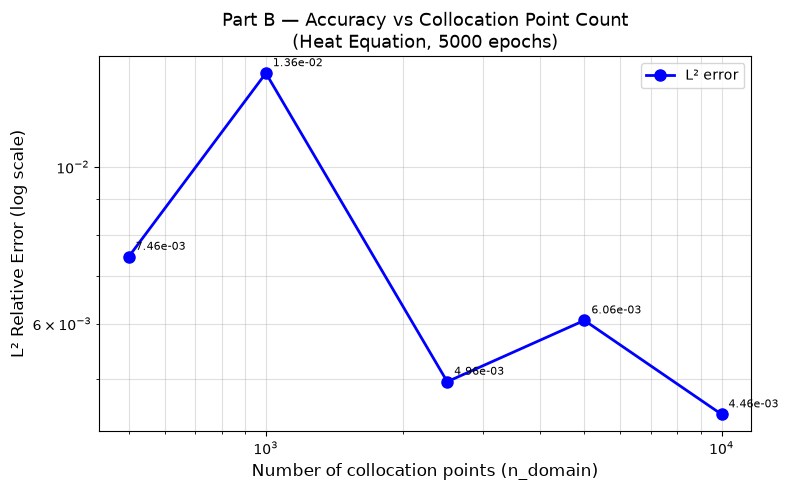


Observation: L² error decreases as collocation count increases,
but with diminishing returns — roughly logarithmic improvement.
Beyond ~5000 points, the bottleneck shifts to network capacity and training epochs.


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(colloc_counts, l2_vs_colloc, "bo-", lw=2, ms=8, label="L² error")
ax.set_xlabel("Number of collocation points (n_domain)", fontsize=12)
ax.set_ylabel("L² Relative Error (log scale)", fontsize=12)
ax.set_title("Part B — Accuracy vs Collocation Point Count\n(Heat Equation, 5000 epochs)", fontsize=13)
ax.grid(True, alpha=0.4, which="both")
ax.legend(fontsize=10)

for x_c, y_c in zip(colloc_counts, l2_vs_colloc):
    ax.annotate(f"{y_c:.2e}", (x_c, y_c), textcoords="offset points",
                xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.show()

print("\nObservation: L² error decreases as collocation count increases,")
print("but with diminishing returns — roughly logarithmic improvement.")
print("Beyond ~5000 points, the bottleneck shifts to network capacity and training epochs.")

---
## Part C — Wave Equation

**Problem:**
```
uₜₜ = u_xx,   x ∈ [0,1],  t ∈ [0,1],  c=1
u(x,0) = sin(πx),   uₜ(x,0) = 0     ← ICs
u(0,t) = 0,          u(1,t) = 0     ← BCs
```

**Analytical solution:** `u(x,t) = sin(πx) · cos(πt)`


In [10]:
def u_exact_wave(x):
    return np.sin(np.pi * x[:, 0:1]) * np.cos(np.pi * x[:, 1:2])

# ── PDE: u_tt - u_xx = 0 ─────────────────────────────────────────────────────
def wave_pde(x, y):
    dy_tt = dde.grad.hessian(y, x, i=1, j=1)   # ∂²u/∂t²
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)   # ∂²u/∂x²
    return dy_tt - dy_xx

# ── Domain ────────────────────────────────────────────────────────────────────
geom_w     = dde.geometry.Interval(0, 1)
time_w     = dde.geometry.TimeDomain(0, 1)
geomtime_w = dde.geometry.GeometryXTime(geom_w, time_w)

# ── BCs and ICs ───────────────────────────────────────────────────────────────
bc_w = dde.icbc.DirichletBC(
    geomtime_w, lambda x: 0,
    lambda _, on_boundary: on_boundary
)
ic_w_disp = dde.icbc.IC(           # u(x,0) = sin(πx)
    geomtime_w,
    lambda x: np.sin(np.pi * x[:, 0:1]),
    lambda _, on_initial: on_initial
)
# u_t(x,0) = 0  — implemented as an OperatorBC on the initial line
def ic_vel(x, y, X):
    """Enforce du/dt = 0 at t=0"""
    return dde.grad.jacobian(y, x, i=0, j=1)

ic_w_vel = dde.icbc.OperatorBC(
    geomtime_w,
    ic_vel,
    lambda x, on_initial: on_initial
)

data_w = dde.data.TimePDE(
    geomtime_w, wave_pde, [bc_w, ic_w_disp, ic_w_vel],
    num_domain=5000, num_boundary=200, num_initial=400
)
net_w   = dde.nn.FNN([2] + [64]*4 + [1], "tanh", "Glorot normal")
model_w = dde.Model(data_w, net_w)

model_w.compile("adam", lr=1e-3)
losshistory_w, _ = model_w.train(iterations=15000, display_every=5000)
print("Wave equation training complete ✓")

Compiling model...
'compile' took 0.000243 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [1.83e-03, 1.68e-02, 4.19e-01, 7.54e-03]    [1.83e-03, 1.68e-02, 4.19e-01, 7.54e-03]    []  
5000      [4.90e-05, 1.27e-05, 2.06e-05, 1.17e-04]    [4.90e-05, 1.27e-05, 2.06e-05, 1.17e-04]    []  
10000     [2.03e-04, 5.00e-05, 4.44e-05, 1.07e-04]    [2.03e-04, 5.00e-05, 4.44e-05, 1.07e-04]    []  
15000     [7.16e-05, 6.85e-06, 2.14e-05, 1.16e-04]    [7.16e-05, 6.85e-06, 2.14e-05, 1.16e-04]    []  

Best model at step 5000:
  train loss: 2.00e-04
  test loss: 2.00e-04
  test metric: []

'train' took 135.578119 s

Wave equation training complete ✓


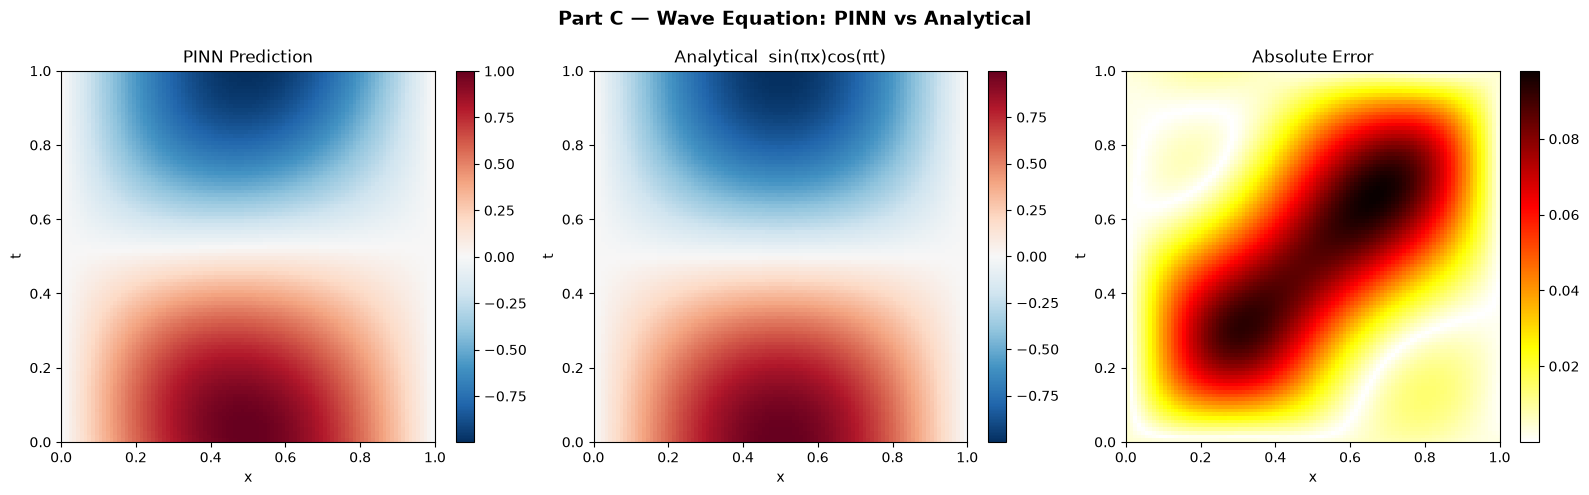

L² Relative Error (Wave Equation): 9.2117e-02


In [11]:
# Evaluate on same grid
u_wave_pinn  = model_w.predict(XT).reshape(100, 100)
u_wave_exact = u_exact_wave(XT).reshape(100, 100)
u_wave_err   = np.abs(u_wave_pinn - u_wave_exact)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Part C — Wave Equation: PINN vs Analytical", fontsize=14, fontweight="bold")

for ax, field, title, cmap in zip(
    axes,
    [u_wave_pinn, u_wave_exact, u_wave_err],
    ["PINN Prediction", "Analytical  sin(πx)cos(πt)", "Absolute Error"],
    ["RdBu_r", "RdBu_r", "hot_r"]
):
    im = ax.imshow(field, origin="lower", extent=[0, 1, 0, 1], aspect="auto", cmap=cmap)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("x"); ax.set_ylabel("t")

plt.tight_layout()
plt.show()

l2_wave = dde.metrics.l2_relative_error(u_wave_exact.ravel(), u_wave_pinn.ravel())
print(f"L² Relative Error (Wave Equation): {l2_wave:.4e}")

### Part C — Qualitative Comparison

| Property | Heat Equation | Wave Equation |
|---|---|---|
| Type | Parabolic | Hyperbolic |
| Behaviour | Exponential decay — amplitude → 0 as t→∞ | Periodic oscillation — amplitude preserved |
| Shape | Smooth envelope that shrinks | Standing wave pattern, no decay |
| PINN difficulty | Easier — smooth, monotone in time | Harder — oscillatory, network must track phase |

**Heat:** `u(x,t) = exp(−0.4π²t) · sin(πx)` — the spatial mode decays exponentially. At t=1 the amplitude is `exp(−0.4π²) ≈ 0.02`.

**Wave:** `u(x,t) = sin(πx) · cos(πt)` — a standing wave. At t=0.5 the entire field flips sign; at t=1 it returns to the initial shape. This oscillatory time behaviour engages the network's spectral bias — similar to high-ω₀ in Week 2.
